# Week 4 Machine Learning and Data Mining for Health Services

## Reproducible modeling evaluation and assurance

This guided lab translates Chapter 4 into an executable lesson. We will build a classification workflow, but the main subject is **how to reason about an ML project**: define the decision, protect the evaluation, connect metrics to consequences, and know when the evidence is too weak for use.

> **Educational boundary:** Nothing in this notebook is clinically validated. The public breast-mass dataset is historical and incomplete for contemporary clinical translation. The two operational datasets are entirely synthetic. Do not use any output for diagnosis, treatment, eligibility, payment, fraud determination, or another real decision.

- **Estimated class time:** 120 minutes
- **Positive class in the classification example:** malignant record = 1
- **Reproducibility seed:** 42

## Learning objectives

By the end of the lesson, learners will be able to:

1. **Differentiate** supervised, unsupervised, semi-supervised, and self-supervised learning and match each to an appropriate health-service question.
2. **Formulate** classification, regression, ranking, clustering, and anomaly-detection tasks using an explicit population, prediction time, input, target, user, and action.
3. **Build** a reproducible train-validation-test workflow with preprocessing inside a scikit-learn pipeline.
4. **Compare** a baseline and candidate models using discrimination, calibration, threshold metrics, and operational capacity rather than accuracy alone.
5. **Interpret** coefficients, permutation importance, clusters, and anomaly scores without making causal or clinical-validity claims.
6. **Evaluate** a proposed model through Evaluation, Responsible AI, and Secure AI checkpoints.

### Lesson map

`decision → data and labels → partition → pipeline → baseline → validation → threshold/capacity → locked test → interpretation → assurance`

## Instructor agenda

| Time | Segment | Teaching move |
|---:|---|---|
| 0-15 min | Decision framing and task families | Ask what action changes before naming an algorithm |
| 15-30 min | Dataset provenance and inspection | Separate a convenient label from a validated construct |
| 30-50 min | Partitioning, preprocessing, and leakage | Use the time-travel question for every feature |
| 50-75 min | Baselines, metrics, calibration, thresholds | Translate each error into workload or missed cases |
| 75-90 min | Model comparison and interpretation | Require evidence before accepting complexity |
| 90-108 min | Clustering, regression, anomaly triage | Contrast the output and validation question for each task |
| 108-120 min | Responsible and Secure AI | Conduct a release-readiness critique and exit ticket |

**Before revealing code output**, ask learners to predict what they expect and what evidence would change their conclusion.

# 1 Decision first not algorithm first

A model is only one component of a health-service intervention. A defensible project specifies:

- **Population and unit:** Who or what receives one prediction?
- **Prediction time:** At what exact moment must inputs be available?
- **Target:** What event or quantity is estimated, and is it a valid construct or a proxy?
- **User and action:** Who sees the output, and what may change because of it?
- **Comparator:** What rule, forecast, workflow, or non-ML redesign must the model beat?
- **Consequences:** What happens after a false positive, false negative, large regression error, or unstable cluster?

### Think pair share

A hospital wants to “predict delayed discharge.” Rewrite that request as a testable claim. Include the prediction time, permissible inputs, outcome horizon, decision owner, intended action, and comparator.

<details><summary>Instructor notes</summary>

A useful answer might be: “Using information available by midnight after admission, estimate whether discharge will occur after the service-line target so the next-day bed-management team can initiate an existing barrier-removal workflow; compare against current service-line rules and a process dashboard.” Ask whether prediction is needed if known transportation, pharmacy, or equipment bottlenecks can be fixed directly.

</details>

# 2 Learning paradigms and task families

| Paradigm | Supervision | Typical outputs | Health-service example | Main validation question |
|---|---|---|---|---|
| Supervised | Features plus labels | Class, probability, number, rank | Denial risk or length of stay | Does it generalize and support the intended action? |
| Unsupervised | Features without a target | Cluster, dimension, anomaly score | Utilization segments or unusual claims | Is the structure stable, interpretable, and useful? |
| Semi-supervised | Few labeled plus many unlabeled records | Class or representation | Extend expensive chart-review labels | Do unlabeled records help without amplifying biased seed labels? |
| Self-supervised | A proxy task derived from raw data | Reusable representation | Pretrain on notes, images, or waveforms | Does the representation transfer safely to the downstream task? |

Task and action are not interchangeable:

- **Classification:** estimate a category or class probability.
- **Regression:** estimate a continuous outcome such as days.
- **Ranking:** order records when review capacity is limited.
- **Clustering:** construct groups from similarity; there is no supplied correct label.
- **Anomaly detection:** estimate unusualness for investigation, not guilt or error.

**Quick check:** If reviewers can inspect only 100 claims each week, why might *ranking* be the operational task even when a binary classifier produces the score?

# 3 Environment data and provenance

The main dataset is the **Breast Cancer Wisconsin Diagnostic** dataset from the UCI Machine Learning Repository (ID 17, DOI [10.24432/C5DW2B](https://doi.org/10.24432/C5DW2B)). It contains 569 historical records and 30 real-valued features computed from digitized fine-needle aspirate images.

Why it works for teaching: it is small, numeric, and supports scaling, classification, model comparison, calibration, and interpretation.

Why it is not clinical evidence: it lacks contemporary populations, demographics, multiple sites, acquisition variation, longitudinal context, workflow data, and prospective validation. High internal scores cannot fill those gaps.

In [1]:
from pathlib import Path
import hashlib
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

from IPython.display import display
from sklearn.base import clone
from sklearn.calibration import CalibrationDisplay
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import IsolationForest, RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", context="notebook")


def find_repo_root() -> Path:
    # Find the repository whether the kernel starts at root or by the notebook.
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "week4" / "data").is_dir():
            return candidate
    raise FileNotFoundError("Could not find CodeBaseHI634/week4/data from the current directory.")


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "week4" / "data"

print(f"Python:       {platform.python_version()}")
print(f"NumPy:        {np.__version__}")
print(f"pandas:       {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"Data folder:  {DATA_DIR}")

Python:       3.14.5
NumPy:        2.5.3
pandas:       3.0.5
scikit-learn: 1.9.1
Data folder:  /Users/rahulsharma/Dropbox/UAB/HI-634/CodeBaseHI634/week4/data


In [2]:
def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


wdbc_path = DATA_DIR / "breast_cancer_wisconsin_diagnostic.csv"
expected_sha256 = "3487b754ff02c93cdc8a18afafe223961d9cfbfdb932e57483e52581042767d7"
observed_sha256 = sha256_file(wdbc_path)
assert observed_sha256 == expected_sha256, "The approved dataset snapshot has changed."

raw = pd.read_csv(wdbc_path)
X = raw.drop(columns=["ID", "Diagnosis"]).apply(pd.to_numeric, errors="coerce")
y = raw["Diagnosis"].str.strip().str.upper().eq("M").astype(int).rename("malignant")

assert X.shape == (569, 30)
assert set(y.unique()) == {0, 1}

print("Feature matrix:", X.shape)
print("Target counts (0=benign, 1=malignant):")
display(y.value_counts().sort_index().rename("records").to_frame())
display(raw.head(3))

Feature matrix: (569, 30)
Target counts (0=benign, 1=malignant):


,records
malignant,
0,357
1,212


,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,radius2,texture2,perimeter2,area2,smoothness2,compactness2,concavity2,concave_points2,symmetry2,fractal_dimension2,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,842302,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,842517,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,84300903,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M


## Inspect before modeling

Confirm the unit of analysis, identifiers, feature types, missingness, implausible values, duplicates, label definition, and prevalence. An absent value can encode a workflow decision; imputation does not repair an invalid or biased measurement process.

**Prediction-time test:** Could the system know this feature at the moment it must act through an approved production data flow? If not, using it is target leakage.

Duplicate feature rows: 0
Malignant prevalence:   0.373


,dtype,missing_n,missing_pct,unique_n,minimum,median,maximum
radius1,float64,0,0.0,456,6.981,13.370,28.110
texture1,float64,0,0.0,479,9.710,18.840,39.280
perimeter1,float64,0,0.0,522,43.790,86.240,188.500
area1,float64,0,0.0,539,143.500,551.100,2501.000
smoothness1,float64,0,0.0,474,0.053,0.096,0.163
compactness1,float64,0,0.0,537,0.019,0.093,0.345
concavity1,float64,0,0.0,537,0.000,0.062,0.427
concave_points1,float64,0,0.0,542,0.000,0.034,0.201
symmetry1,float64,0,0.0,432,0.106,0.179,0.304
fractal_dimension1,float64,0,0.0,499,0.050,0.062,0.097


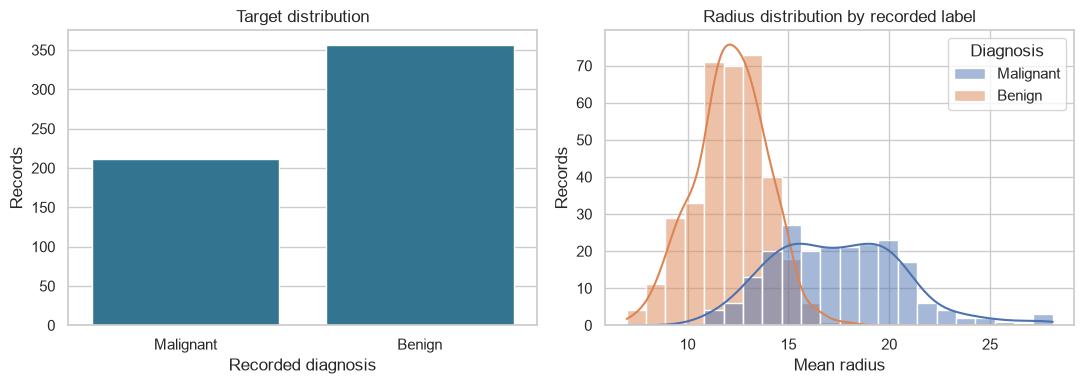

In [3]:
summary = pd.DataFrame(
    {
        "dtype": X.dtypes.astype(str),
        "missing_n": X.isna().sum(),
        "missing_pct": X.isna().mean().mul(100),
        "unique_n": X.nunique(dropna=True),
        "minimum": X.min(),
        "median": X.median(),
        "maximum": X.max(),
    }
)

print(f"Duplicate feature rows: {X.duplicated().sum()}")
print(f"Malignant prevalence:   {y.mean():.3f}")
display(summary.head(10).round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x=y.map({0: "Benign", 1: "Malignant"}), ax=axes[0], color="#247BA0")
axes[0].set(title="Target distribution", xlabel="Recorded diagnosis", ylabel="Records")

sns.histplot(
    data=pd.DataFrame({"radius1": X["radius1"], "Diagnosis": y.map({0: "Benign", 1: "Malignant"})}),
    x="radius1",
    hue="Diagnosis",
    kde=True,
    ax=axes[1],
)
axes[1].set(title="Radius distribution by recorded label", xlabel="Mean radius", ylabel="Records")
plt.tight_layout()
plt.show()

### Pause and interpret

1. A majority-class model could exceed 60% accuracy here. What would its sensitivity be for malignant records?
2. Several radius, perimeter, and area features are correlated. Does correlation make them interchangeable or causal?
3. The feature table lacks a patient-level identifier. What leakage check can we **not** perform?

<details><summary>Instructor notes</summary>

The all-benign model has sensitivity 0. Correlated measurements may be redundant, but correlation neither establishes interchangeability nor causation. Without a patient identifier, we cannot verify whether repeated specimens from the same person cross partitions; record this as a limitation.

</details>

# 4 Partition before learning

We create 60% training, 20% validation, and 20% final test subsets. The validation set supports model and threshold decisions. The test set remains untouched until the complete pipeline and operating threshold are locked.

A stratified random split is appropriate for this mechanics lesson, not necessarily for deployment. Repeated patients require grouped splitting; later deployment requires temporal validation; transport to another organization requires site-held-out or external validation.

In [4]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.25,  # 25% of 80% is 20% of the full dataset
    stratify=y_dev,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    {
        "records": [len(y_train), len(y_val), len(y_test)],
        "malignant_records": [y_train.sum(), y_val.sum(), y_test.sum()],
        "malignant_prevalence": [y_train.mean(), y_val.mean(), y_test.mean()],
    },
    index=["train", "validation", "test"],
)
display(split_summary.round(3))

,records,malignant_records,malignant_prevalence
train,341,127,0.372
validation,114,43,0.377
test,114,42,0.368


## Leakage-safe preprocessing

Imputation and scaling learn values from data. If they are fit before a split, information from validation or test records influences model development. A `Pipeline` keeps learned transformations inside each training fit and cross-validation fold.

- **Common mistake:** `StandardScaler().fit_transform(X)` followed by a split.
- **Recommended pattern:** split raw records first, then fit a pipeline on training data.

In [5]:
numeric_features = X.columns.tolist()

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
preprocess = ColumnTransformer(
    transformers=[("numeric", numeric_pipeline, numeric_features)],
    remainder="drop",
)
logistic_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            LogisticRegression(
                C=1.0,
                max_iter=2_000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

logistic_model.fit(X_train, y_train)
validation_probability = logistic_model.predict_proba(X_val)[:, 1]
print("Pipeline fitted on training records only.")

Pipeline fitted on training records only.


# 5 Baseline and binary classification metrics

A baseline asks whether the model improves on a trivial or existing process. Accuracy alone is insufficient because it collapses four different outcomes.

- **Sensitivity:** fraction of actual positives detected.
- **Specificity:** fraction of actual negatives correctly excluded.
- **Precision / PPV:** fraction of positive predictions that are truly positive.
- **ROC-AUC:** ranking discrimination across thresholds.
- **PR-AUC:** precision-recall tradeoff, especially informative when positives are uncommon.
- **Brier score:** mean squared probability error; lower is better.

In [6]:
def evaluate_binary(y_true, probability, threshold=0.50):
    prediction = (np.asarray(probability) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {
        "accuracy": accuracy_score(y_true, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "sensitivity": recall_score(y_true, prediction, zero_division=0),
        "specificity": tn / (tn + fp),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probability),
        "pr_auc": average_precision_score(y_true, probability),
        "brier": brier_score_loss(y_true, probability),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "alerts": int(prediction.sum()),
    }


baseline = DummyClassifier(strategy="prior")
baseline.fit(X_train, y_train)
baseline_probability = baseline.predict_proba(X_val)[:, 1]

validation_results = pd.DataFrame(
    {
        "Prevalence baseline": evaluate_binary(y_val, baseline_probability),
        "Logistic regression": evaluate_binary(y_val, validation_probability),
    }
).T
display(validation_results.round(3))

,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1,roc_auc,pr_auc,brier,tn,fp,fn,tp,alerts
Prevalence baseline,0.623,0.500,0.000,0.000,1.000,0.000,0.500,0.377,0.235,71.0,0.0,43.0,0.0,0.0
Logistic regression,0.974,0.974,0.955,0.977,0.972,0.966,0.996,0.995,0.020,69.0,2.0,1.0,42.0,44.0


### Decision translation

For each validation result, state the number of missed malignant records, false alerts, and total alerts. Then explain why the baseline's accuracy can sound acceptable while its detection is useless.

A strong internal result is still only a result on this small historical sample. It does not establish contemporary performance, transportability, patient benefit, or readiness for use.

# 6 Discrimination calibration thresholds and capacity

A model can rank records correctly and still assign probabilities that are systematically too high or too low. A classification threshold is an operational choice, not a natural constant. Changing it redistributes missed cases and review workload.

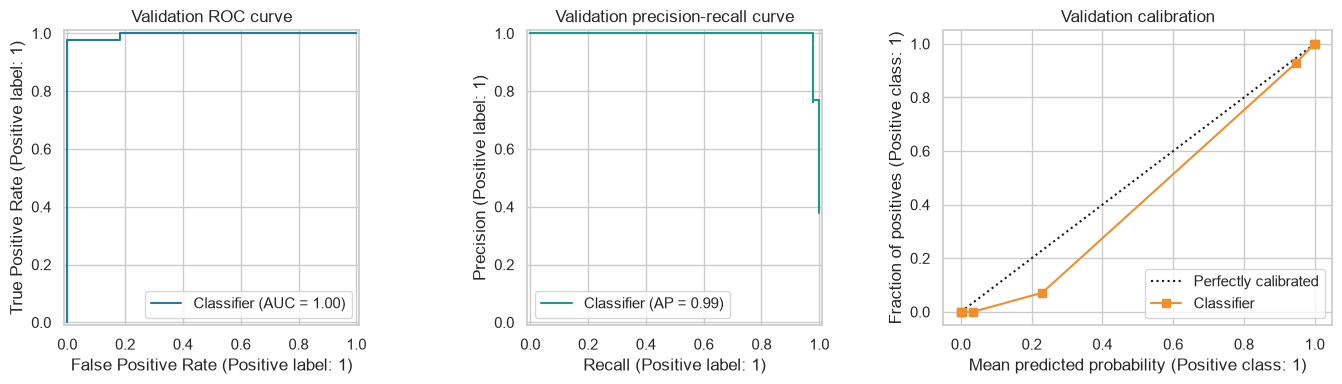

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
RocCurveDisplay.from_predictions(
    y_val,
    validation_probability,
    ax=axes[0],
    curve_kwargs={"color": "#247BA0"},
)
PrecisionRecallDisplay.from_predictions(
    y_val,
    validation_probability,
    ax=axes[1],
    curve_kwargs={"color": "#1B998B"},
)
CalibrationDisplay.from_predictions(
    y_val,
    validation_probability,
    n_bins=8,
    strategy="quantile",
    ax=axes[2],
    color="#F28E2B",
)
axes[0].set_title("Validation ROC curve")
axes[1].set_title("Validation precision-recall curve")
axes[2].set_title("Validation calibration")
plt.tight_layout()
plt.show()

In [8]:
threshold_rows = []
for threshold in np.arange(0.10, 0.91, 0.05):
    threshold_rows.append(
        {"threshold": threshold, **evaluate_binary(y_val, validation_probability, threshold)}
    )
threshold_table = pd.DataFrame(threshold_rows)

minimum_sensitivity = 0.95  # teaching constraint, not a clinical requirement
eligible = threshold_table.loc[threshold_table["sensitivity"] >= minimum_sensitivity]
selected_row = eligible.sort_values(
    ["specificity", "precision", "threshold"], ascending=[False, False, False]
).iloc[0]
selected_threshold = float(selected_row["threshold"])

print(f"Teaching rule: sensitivity >= {minimum_sensitivity:.0%}, then maximize specificity.")
print(f"Selected validation threshold: {selected_threshold:.2f}")
display(
    threshold_table[
        ["threshold", "sensitivity", "specificity", "precision", "fp", "fn", "alerts"]
    ].round(3)
)

Teaching rule: sensitivity >= 95%, then maximize specificity.
Selected validation threshold: 0.90


,threshold,sensitivity,specificity,precision,fp,fn,alerts
0,0.10,1.000,0.817,0.768,13,0,56
1,0.15,0.977,0.859,0.808,10,1,52
2,0.20,0.977,0.887,0.840,8,1,50
3,0.25,0.977,0.901,0.857,7,1,49
4,0.30,0.977,0.944,0.913,4,1,46
5,0.35,0.977,0.972,0.955,2,1,44
6,0.40,0.977,0.972,0.955,2,1,44
7,0.45,0.977,0.972,0.955,2,1,44
8,0.50,0.977,0.972,0.955,2,1,44
9,0.55,0.977,0.972,0.955,2,1,44


**Discuss before proceeding:** Is a 95% sensitivity constraint appropriate? We cannot answer from the dataset. The choice requires an intended action, the consequences of missed and unnecessary review, available capacity, uncertainty, subgroup effects, and a fallback pathway. Small validation sets also make precise thresholds unstable.

In [9]:
validation_rank = pd.DataFrame(
    {"observed": y_val.to_numpy(), "score": validation_probability}
).sort_values("score", ascending=False)

capacity_fraction = 0.20
k = int(np.ceil(capacity_fraction * len(validation_rank)))
review_queue = validation_rank.head(k)

precision_at_k = review_queue["observed"].mean()
capture_at_k = review_queue["observed"].sum() / validation_rank["observed"].sum()
prevalence = validation_rank["observed"].mean()
lift_at_k = precision_at_k / prevalence

pd.Series(
    {
        "records available": len(validation_rank),
        "records reviewed": k,
        "precision at capacity": precision_at_k,
        "positive capture at capacity": capture_at_k,
        "lift over random selection": lift_at_k,
    }
).to_frame("value")

,value
records available,114.000000
records reviewed,23.000000
precision at capacity,1.000000
positive capture at capacity,0.534884
lift over random selection,2.651163


**Ranking prompt:** What happens to people consistently below the queue cutoff? Capacity is a real constraint, but it is not automatically a fair allocation rule. Evaluate queue stability, subgroup representation, review time, downstream benefit, and recourse.

# 7 Compare complete pipelines then test once

Candidate models must use identical development folds and include all learned preprocessing. We compare a transparent regularized logistic model with a constrained decision tree and a random forest. Complexity must earn its additional explanation, maintenance, latency, and security burden.

In [10]:
unscaled_preprocess = ColumnTransformer(
    [("numeric", SimpleImputer(strategy="median"), numeric_features)]
)
models = {
    "Logistic regression": logistic_model,
    "Decision tree": Pipeline(
        [
            ("preprocess", unscaled_preprocess),
            (
                "model",
                DecisionTreeClassifier(
                    max_depth=4,
                    min_samples_leaf=8,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Random forest": Pipeline(
        [
            ("preprocess", unscaled_preprocess),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300,
                    min_samples_leaf=3,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "balanced_accuracy": "balanced_accuracy",
    "neg_brier": "neg_brier_score",
}

comparison_rows = []
for name, estimator in models.items():
    scores = cross_validate(estimator, X_dev, y_dev, cv=cv, scoring=scoring, n_jobs=-1)
    comparison_rows.append(
        {
            "model": name,
            "roc_auc_mean": scores["test_roc_auc"].mean(),
            "roc_auc_sd": scores["test_roc_auc"].std(),
            "pr_auc_mean": scores["test_pr_auc"].mean(),
            "balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
            "brier_mean": -scores["test_neg_brier"].mean(),
        }
    )

comparison = pd.DataFrame(comparison_rows).sort_values("roc_auc_mean", ascending=False)
display(comparison.round(3))

,model,roc_auc_mean,roc_auc_sd,pr_auc_mean,balanced_accuracy_mean,brier_mean
0,Logistic regression,0.996,0.005,0.995,0.969,0.019
2,Random forest,0.988,0.005,0.986,0.957,0.035
1,Decision tree,0.953,0.029,0.931,0.912,0.060


### Lock the analytical choice

The regularized logistic pipeline is selected because it provides strong cross-validated performance with a simpler, more inspectable model. This is a dataset-specific teaching decision, not a claim that logistic regression is universally best.

The model and threshold are now locked. The next cell is the first and only planned test-set evaluation in the lesson. In real work, changing the model after seeing this output would convert the test set into development data.

In [11]:
final_model = clone(logistic_model).fit(X_dev, y_dev)
test_probability = final_model.predict_proba(X_test)[:, 1]
test_results = pd.Series(
    evaluate_binary(y_test, test_probability, threshold=selected_threshold),
    name="locked_test_result",
)
display(test_results.round(3).to_frame())

,locked_test_result
accuracy,0.921
balanced_accuracy,0.893
precision,1.000
sensitivity,0.786
specificity,1.000
f1,0.880
roc_auc,0.996
pr_auc,0.994
brier,0.021
tn,72.000


**Interpret narrowly:** Within this historical public dataset and deterministic internal split, the logistic pipeline separates the recorded labels well. The small test set produces uncertain estimates. The result does not demonstrate performance at another site or time, clinical benefit, a safe threshold, or regulatory readiness.

# 8 Interpret model behavior without claiming causality

Standardized logistic coefficients summarize conditional model associations. Permutation importance measures the decrease in a chosen performance score when one feature is shuffled. Correlated features can distribute or mask importance in both methods.

Neither method shows that a feature causes the outcome, that changing it changes risk, or that the model is valid for a clinical use.

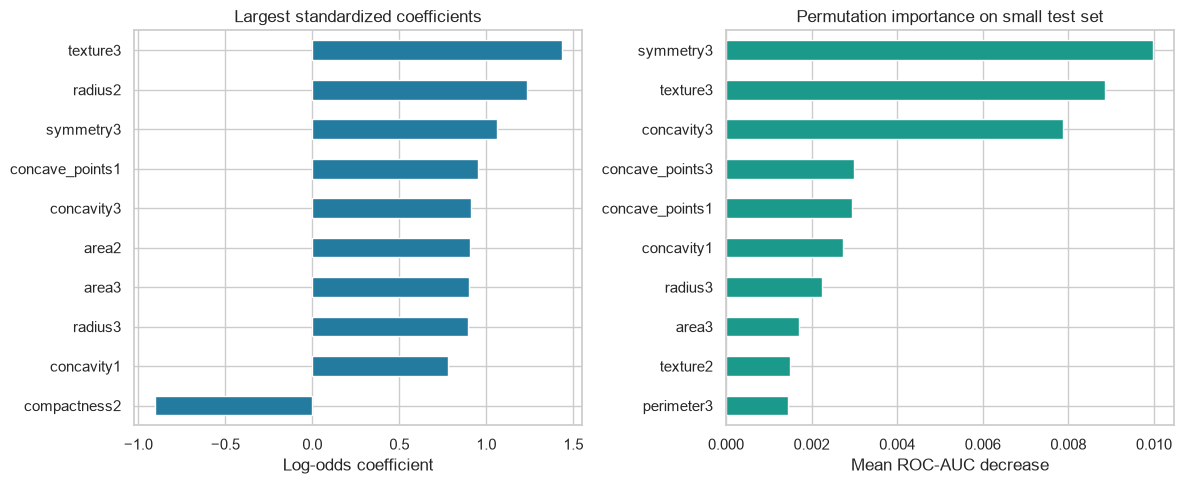

,coefficient_feature,standardized_log_odds_coefficient,permutation_feature,mean_roc_auc_decrease
0,texture3,1.4341,symmetry3,0.0100
1,radius2,1.2333,texture3,0.0089
2,symmetry3,1.0613,concavity3,0.0079
3,concave_points1,0.9528,concave_points3,0.0030
4,concavity3,0.9114,concave_points1,0.0029
5,area2,0.9090,concavity1,0.0027
6,compactness2,-0.9069,radius3,0.0022
7,area3,0.9005,area3,0.0017
8,radius3,0.8970,texture2,0.0015
9,concavity1,0.7823,perimeter3,0.0015


In [12]:
transformed_names = [
    name.removeprefix("numeric__")
    for name in final_model.named_steps["preprocess"].get_feature_names_out()
]
coefficients = pd.Series(
    final_model.named_steps["model"].coef_[0],
    index=transformed_names,
    name="standardized_log_odds_coefficient",
).sort_values(key=np.abs, ascending=False)

permutation = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
permutation_summary = pd.Series(
    permutation.importances_mean,
    index=X.columns,
    name="mean_roc_auc_decrease",
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
coefficients.head(10).sort_values().plot.barh(ax=axes[0], color="#247BA0")
axes[0].set(title="Largest standardized coefficients", xlabel="Log-odds coefficient")
permutation_summary.head(10).sort_values().plot.barh(ax=axes[1], color="#1B998B")
axes[1].set(title="Permutation importance on small test set", xlabel="Mean ROC-AUC decrease")
plt.tight_layout()
plt.show()

importance_comparison = pd.DataFrame(
    {
        "coefficient_feature": coefficients.index[:10],
        "standardized_log_odds_coefficient": coefficients.iloc[:10].to_numpy(),
        "permutation_feature": permutation_summary.index[:10],
        "mean_roc_auc_decrease": permutation_summary.iloc[:10].to_numpy(),
    }
)
display(importance_comparison.round(4))

**Language check:** Rewrite “the top feature causes malignancy” as a defensible statement.

<details><summary>Instructor notes</summary>

Example: “In this fitted pipeline and historical sample, this feature had one of the largest standardized conditional associations or permutation effects on internal discrimination. Correlation, sampling uncertainty, and the feature-extraction process limit interpretation; no causal effect is established.”

</details>

# 9 Unsupervised learning patient segmentation example

We fit K-means without using the diagnosis target. Scaling is essential because Euclidean distance would otherwise be dominated by large-range variables. Silhouette score describes separation under the chosen geometry; it does not reveal true biological or patient types.

In [13]:
cluster_preprocess = Pipeline(
    [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)
X_cluster = cluster_preprocess.fit_transform(X)

cluster_rows = []
cluster_assignments = {}
for k_clusters in range(2, 6):
    kmeans = KMeans(n_clusters=k_clusters, n_init=20, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(X_cluster)
    cluster_assignments[k_clusters] = labels
    cluster_rows.append(
        {
            "k": k_clusters,
            "silhouette": silhouette_score(X_cluster, labels),
            "smallest_cluster": pd.Series(labels).value_counts().min(),
        }
    )

cluster_results = pd.DataFrame(cluster_rows)
display(cluster_results.round(3))
print("Post hoc description only; diagnosis was not used to fit the clusters:")
display(pd.crosstab(cluster_assignments[2], y, normalize="index").round(3))

,k,silhouette,smallest_cluster
0,2,0.345,189
1,3,0.314,100
2,4,0.280,37
3,5,0.159,36


Post hoc description only; diagnosis was not used to fit the clusters:


malignant,0,1
row_0,,
0,0.074,0.926
1,0.903,0.097


Before using clusters to design services, require stability across resamples and sites, domain and stakeholder review, non-stigmatizing descriptions, and evidence that the groups support a better action than direct eligibility rules or modeling of the real decision.

# 10 Regression synthetic length of stay

Length of stay is continuous. Converting it to “long” versus “not long” discards information and creates an arbitrary cutoff. We compare models using **MAE in days**, **RMSE in days**, and **R-squared**.

The file is deterministic synthetic educational data, not a real hospital population.

In [14]:
los = pd.read_csv(DATA_DIR / "synthetic_length_of_stay.csv")
los_features = ["age", "comorbidity_count", "emergency_admission", "lab_severity_index"]
X_los = los[los_features]
y_los = los["length_of_stay_days"]

X_los_train, X_los_test, y_los_train, y_los_test = train_test_split(
    X_los, y_los, test_size=0.20, random_state=RANDOM_STATE
)
regressors = {
    "Median baseline": DummyRegressor(strategy="median"),
    "Ridge regression": Pipeline(
        [("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))]
    ),
    "Random forest": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

regression_rows = []
for name, estimator in regressors.items():
    estimator.fit(X_los_train, y_los_train)
    prediction = estimator.predict(X_los_test)
    regression_rows.append(
        {
            "model": name,
            "MAE_days": mean_absolute_error(y_los_test, prediction),
            "RMSE_days": mean_squared_error(y_los_test, prediction) ** 0.5,
            "R2": r2_score(y_los_test, prediction),
        }
    )
regression_results = pd.DataFrame(regression_rows).sort_values("MAE_days")
display(regression_results.round(3))

,model,MAE_days,RMSE_days,R2
1,Ridge regression,1.016,1.284,0.488
2,Random forest,1.076,1.337,0.446
0,Median baseline,1.430,1.799,-0.004


**Discuss:** Why might the simpler ridge model outperform the forest? The synthetic outcome is largely additive. In a real study, evaluate temporal and site transport, censoring, prediction intervals, service-line error, and whether forecasts improve bed management.

# 11 Anomaly detection synthetic claims triage

Anomaly detection estimates unusualness relative to a reference distribution. An unusual claim is not necessarily fraudulent, erroneous, or inappropriate. The output should prioritize human review, not automatically deny payment.

In [15]:
claims = pd.read_csv(DATA_DIR / "synthetic_claims.csv")
claim_features = ["allowed_amount", "service_count", "days_since_last_claim"]

anomaly_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "model",
            IsolationForest(
                n_estimators=300,
                contamination=0.02,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
claims["flagged_for_review"] = anomaly_pipeline.fit_predict(claims[claim_features]) == -1

print("Review workload:")
display(claims["flagged_for_review"].value_counts().rename("records").to_frame())
print("Post hoc simulation check; simulation_group was not used to fit the model:")
display(pd.crosstab(claims["simulation_group"], claims["flagged_for_review"]))
display(
    claims.loc[claims["flagged_for_review"], ["synthetic_claim_id", *claim_features]]
    .sort_values("allowed_amount", ascending=False)
    .head(10)
)

Review workload:


,records
flagged_for_review,
False,980
True,20


Post hoc simulation check; simulation_group was not used to fit the model:


flagged_for_review,False,True
simulation_group,,
common_pattern,979,1
injected_unusual_pattern,1,19


,synthetic_claim_id,allowed_amount,service_count,days_since_last_claim
945,CLM-0981,24673.44,20,2.84
388,CLM-0991,19895.72,35,2.39
561,CLM-1000,18291.75,15,0.06
231,CLM-0995,15152.91,15,0.17
133,CLM-0996,14415.06,32,0.49
941,CLM-0993,13836.49,32,1.92
899,CLM-0997,13326.06,35,2.92
518,CLM-0984,12843.17,26,1.70
917,CLM-0983,12720.23,39,0.60
475,CLM-0989,12684.76,24,1.52


Changing `contamination` changes workload by design. In real operations, track review yield, false accusation, appeals, code changes, distribution shift, and investigator capacity. A clean result on intentionally separated synthetic patterns is not realistic performance evidence.

# 12 Evaluation Responsible AI and Secure AI

Use three assurance lenses throughout the lifecycle, not only after modeling.

| Lens | Questions before release |
|---|---|
| Evaluation | Is the label valid? Was the split aligned with patient, site, and time boundaries? Is there a meaningful comparator? Are discrimination, calibration, threshold consequences, uncertainty, robustness, and external validity adequate for the intended action? |
| Responsible AI | Does the proxy encode unequal access or policy? Are groups represented? Who bears false-positive and false-negative burdens? Do explanations support appropriate reliance? Who can challenge an output or receive a fallback pathway? |
| Secure AI | Who can alter data, labels, code, dependencies, model artifacts, thresholds, or logs? Are access, provenance, checksums, signed artifacts, input validation, monitoring, rollback, incident response, and retirement defined? |

### Release-readiness scenario

A manager sees the high test ROC-AUC and asks to place the notebook behind an API next month. In small groups, write a recommendation: **adopt, modify, restrict, abstain, or advance only to another evaluation stage**. Support the recommendation with at least two items from each lens.

<details><summary>Instructor notes</summary>

The defensible recommendation is not deployment. At most, advance to a prespecified independent validation or carefully governed research stage. Missing evidence includes contemporary and external populations, workflow fit, prospective impact, justified thresholds, uncertainty, subgroup variables, human-factors testing, privacy review, cybersecurity controls, quality management, monitoring, rollback, and accountable decision authority.

</details>

# 13 Review exercises and exit ticket

## In-class review

1. Why must prediction time be defined before feature selection?
2. What does ROC-AUC measure, and what does it not answer about calibration, thresholds, or workload?
3. Why can a majority-class model have acceptable accuracy and zero useful detection?
4. Why might logistic regression be preferred when a more complex model has a similar cross-validated ROC-AUC?
5. What additional evidence is required before using high-silhouette clusters for service design?
6. Name three assets beyond raw data that require integrity controls.

## Optional extension labs

- Replace median with mean imputation and compare cross-validated probability error and coefficient stability.
- Compare scaled and unscaled logistic regression, then explain why nearest-neighbor methods are more sensitive to scale.
- Select a validation threshold for a different sensitivity or capacity constraint, freeze it, and report expected workload.
- Repeat K-means across seeds or bootstrap samples and quantify assignment stability.
- Add a nonlinear age term to the synthetic length-of-stay generator and determine when the forest overtakes ridge regression.
- Change anomaly contamination and graph the number of flags against simulated review capacity.

## Exit ticket

In three sentences, state:

1. one practice that protects evaluation validity;
2. one reason a strong model score may not improve care or operations; and
3. one Responsible AI or Secure AI control that belongs in the method.

# Key takeaways

- Define the decision, workflow, population, prediction time, target, action, and comparator before choosing an algorithm.
- Split before learning and keep every learned transformation inside development-only pipelines.
- Use baselines and connect discrimination, calibration, thresholds, workload, and errors to real consequences.
- Prefer the simplest model that meets the evidence need; complexity has maintenance and security costs.
- Treat coefficients, importance, clusters, and anomaly scores as descriptions of model behavior or data structure, not causal or clinical truths.
- Reproducibility, fairness assessment, privacy, integrity, human authority, monitoring, rollback, and retirement are part of the ML method.

## References and provenance

- HI 634 Chapter 4, *Machine Learning and Data Mining for Health Services: Reproducible Modeling, Evaluation, and Assurance*.
- Wolberg, W., Mangasarian, O., Street, N., and Street, W. [Breast Cancer Wisconsin Diagnostic](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic), UCI Machine Learning Repository, DOI [10.24432/C5DW2B](https://doi.org/10.24432/C5DW2B).
- Synthetic datasets were generated locally with `week4/scripts/generate_synthetic_data.py`; they contain no real patient or claims information.